DATASET - https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria

In [1]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126
%pip install torch_snippets
%pip install scikit-learn
%pip install opencv-python

Looking in indexes: https://download.pytorch.org/whl/cu126
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os 
import torch
import torchvision
# import torch_snippets as ts
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [3]:
id2int = {'Parasitized': 0, 'Uninfected': 1}

In [4]:
## Image transformations
from torchvision import transforms
train_transforms = transforms.Compose([
  # transforms.ToPILImage(),
  transforms.Resize(size=(128, 128)),
  transforms.CenterCrop(size=(128, 128)),
  transforms.ColorJitter(brightness=(0.95, 1.05), contrast=(0.95, 1.05), saturation=0, hue=0),
  transforms.RandomAffine(degrees = 5, translate = (0.01, 0.1)),
  transforms.ToTensor(),
  transforms.Normalize(mean = [0.5, 0.5, 0.5], std=[0.5, 0.5 ,0.5]),
])
val_transforms = transforms.Compose([
  # transforms.ToPILImage(),
  transforms.Resize(size = (128, 128)),
  transforms.CenterCrop(size = (128, 128)),
  transforms.ToTensor(),
  transforms.Normalize(mean = [0.5, 0.5, 0.5], std=[0.5,0.5,0.5])
])

In [5]:
from pathlib import Path
data_path = Path('../data/cell_images')
images_path = Path.joinpath(data_path, 'cell_images')
def images_info(dir_path : Path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [6]:
images_info(images_path)

There are 2 directories and 0 images in '..\data\cell_images\cell_images'.
There are 0 directories and 13780 images in '..\data\cell_images\cell_images\Parasitized'.
There are 0 directories and 13780 images in '..\data\cell_images\cell_images\Uninfected'.


In [ ]:
import random
from PIL import Image
import matplotlib.pyplot as plt

def plot_random_image(image_path=Path, random_seed=42):
  random.seed(random_seed)
  image_path_list = list(image_path.glob('*/*.png'))
  random_image_path = random.choice(image_path_list)
  img_class = random_image_path.parent.stem
  img = Image.open(random_image_path)
  print(f"Random image path: {random_image_path}")
  print(f"Image class: {img_class}")
  print(f"Image height: {img.height}") 
  print(f"Image width: {img.width}")
  plt.imshow(img)

Random image path: ..\data\cell_images\cell_images\Uninfected\C212ThinF_IMG_20151106_110230_cell_157.png
Image class: Uninfected
Image height: 136
Image width: 121


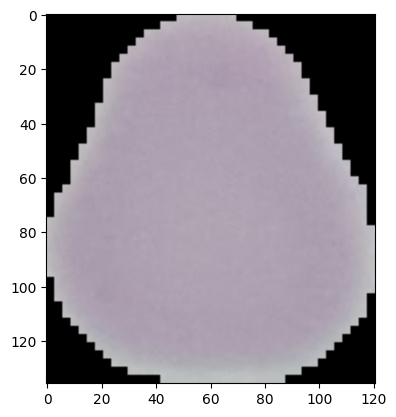

In [8]:
plot_random_image(image_path = images_path)

In [9]:
import os
import shutil
from pathlib import Path
from typing import List
def make_train_test_dirs(train:Path, test:Path, train_files:List[Path], val_files:List[Path]):

  if os.path.isdir(train)==False:
    print("Train directory does not exist! Making one!")
    os.makedirs(train)
    for file in train_files:
      img_class = file.parent.stem
      file_path = Path.joinpath(train, img_class)
      os.makedirs(file_path, exist_ok=True)
      shutil.copy(file, file_path)
    print(f"{len(train_files)} files copied to train directory")

  if os.path.isdir(test)==False:
    print("Test directory does not exist! Making one!")
    os.makedirs(test)
    for file in val_files:
      img_class = file.parent.stem
      file_path = Path.joinpath(test, img_class)
      os.makedirs(file_path, exist_ok=True)
      shutil.copy(file, file_path)
    print(f"{len(val_files)} files copied to test directory")

In [10]:
from sklearn.model_selection import train_test_split
from torchvision import datasets

def create_dataset(images_path : Path, random_seed=42):
  image_files = list(images_path.glob('*/*.png'))
  random.seed(random_seed)
  random.shuffle(image_files)
  train_files, val_files = train_test_split(image_files, random_state=42)
  train = Path.joinpath(data_path, 'train')
  test = Path.joinpath(data_path, 'test')
  make_train_test_dirs(train, test, train_files, val_files)
  train_dataset = datasets.ImageFolder(root=train, transform=train_transforms)
  test_dataset = datasets.ImageFolder(root=test, transform=val_transforms)
  print(f"Train data:\n{train_dataset}\nTest data:\n{test_dataset}")
  return train_dataset, test_dataset


In [11]:
train_dataset, test_dataset = create_dataset(images_path=images_path)

Train data:
Dataset ImageFolder
    Number of datapoints: 20668
    Root location: ..\data\cell_images\train
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               CenterCrop(size=(128, 128))
               ColorJitter(brightness=(0.95, 1.05), contrast=(0.95, 1.05), saturation=None, hue=None)
               RandomAffine(degrees=[-5.0, 5.0], translate=(0.01, 0.1))
               ToTensor()
               Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 6890
    Root location: ..\data\cell_images\test
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               CenterCrop(size=(128, 128))
               ToTensor()
               Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
           )


In [12]:
class_names = train_dataset.classes
class_names

['Parasitized', 'Uninfected']

In [13]:
class_dict = train_dataset.class_to_idx
class_dict

{'Parasitized': 0, 'Uninfected': 1}

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.827451].


Image tensor:
tensor([[[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]],

        [[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]],

        [[-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         ...,
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.],
         [-1., -1., -1.,  ..., -1., -1., -1.]]])
Image shape: torch.Size([3, 128, 128])
Image datatype: torch.float32
Image label: 0
Label da

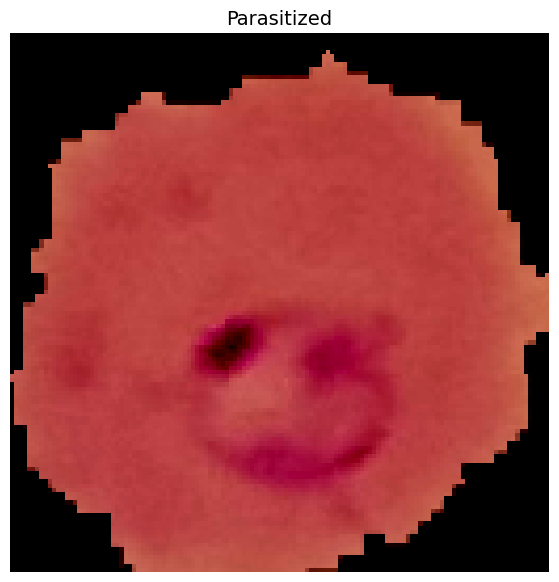

In [14]:
import matplotlib.pyplot as plt
img, label = train_dataset[0][0], train_dataset[0][1]
print(f"Image tensor:\n{img}")
print(f"Image shape: {img.shape}")
print(f"Image datatype: {img.dtype}")
print(f"Image label: {label}")
print(f"Label datatype: {type(label)}")
img_permuted = img.permute(1,2,0)
print(f"Original shape: {img.shape} -> [color_channels, height, width]")
print(f"Image permute shape: {img_permuted.shape} -> [height, width, color_channels]")
plt.figure(figsize=(10, 7))
plt.imshow(img.permute(1,2,0))
plt.axis("off")
plt.title(class_names[label], fontsize=14);


In [15]:
## creating dataloaders
from torch.utils.data import DataLoader

def create_dataloaders(train_dataset:datasets, test_dataset:datasets, batch_size:int=32, num_workers:int=0):
  train_dataloader = DataLoader(dataset = train_dataset, batch_size = batch_size, shuffle=True, num_workers = num_workers)
  test_dataloader = DataLoader(dataset = test_dataset, batch_size = batch_size, num_workers=num_workers, shuffle=False)
  return train_dataloader, test_dataloader

In [16]:
train_dataloader, test_dataloader = create_dataloaders(train_dataset, test_dataset, 32, 0)

In [17]:
len(train_dataloader)

646

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.7490196].


Image shape : torch.Size([32, 3, 128, 128])
Labels : torch.Size([32])
torch.Size([128, 128, 3])


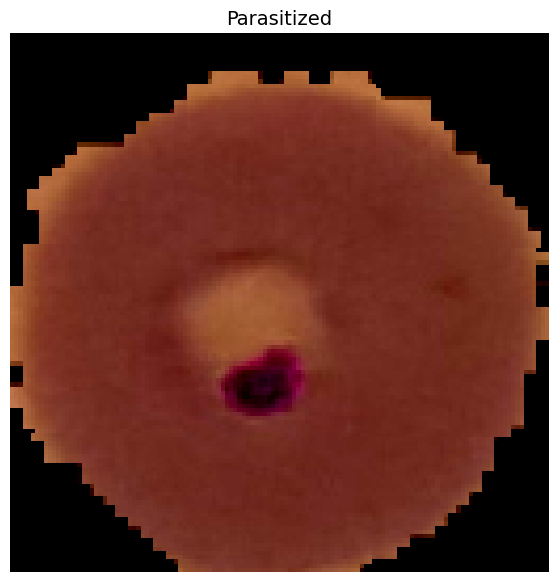

In [18]:
image, label = next(iter(train_dataloader))
print(f"Image shape : {image.shape}")
print(f"Labels : {label.shape}")
print(image[0].permute(1,2,0).shape) 
plt.figure(figsize=(10, 7))
plt.imshow(image[0].permute(1,2,0))
plt.axis("off")
plt.title(class_names[label[0]], fontsize=14);

In [19]:
from torch import nn
def ConvBlock(in_channels, out_channels):
  return nn.Sequential(
    nn.Dropout(0.2),
    nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
    nn.ReLU(inplace=True),  
    nn.BatchNorm2d(num_features=out_channels),
    nn.MaxPool2d(kernel_size=2)
  )

class MalariaClassifier(nn.Module):
  def __init__(self):
    super().__init__()
    self.model = nn.Sequential(
      ConvBlock(3, 64),
      ConvBlock(64, 64),
      ConvBlock(64, 128),
      ConvBlock(128, 256),
      ConvBlock(256, 512),
      ConvBlock(512, 64),
      nn.Flatten(), # [batch_size, channels * H * W]   
      nn.Linear(256, 256),
      nn.Dropout(0.2),
      nn.ReLU(inplace=True),
      nn.Linear(256, len(class_names))
    )
    self.loss_fn = nn.CrossEntropyLoss()

  def forward(self, x): # [batch_size, channels, H, W]
    return self.model(x) # [batch_size, 2(as class_names=2) (probablity distribution of each class)]
  
  def compute_metrics(self, preds, targets): # [batch_size]
    loss = self.loss_fn(preds, targets)
    prediction_probs = torch.softmax(preds, dim=1)
    prediction_labels = torch.argmax(prediction_probs, dim=1)
    accuracy = 0
    accuracy += (prediction_labels == targets).sum().item() / len(prediction_labels) 
    return loss, accuracy

In [20]:
model = MalariaClassifier()
model

MalariaClassifier(
  (model): Sequential(
    (0): Sequential(
      (0): Dropout(p=0.2, inplace=False)
      (1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (2): ReLU(inplace=True)
      (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Dropout(p=0.2, inplace=False)
      (1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (2): ReLU(inplace=True)
      (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Dropout(p=0.2, inplace=False)
      (1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (2): ReLU(inplace=True)
      (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats

In [21]:
# a single prediction using the model
X_train, y_train = next(iter(train_dataloader))
logits = model(X_train)
print(logits) # [batch_size, 2(num_classes)] 
prediction_probs = torch.softmax(logits, dim=1) # dim=1 means along num_classes(columns)
print(prediction_probs) # [batch_size, 2(num_classes)]
prediction_labels = torch.argmax(prediction_probs, dim=1)
print(prediction_labels) # [batch, size]
print(y_train == prediction_labels)
model.compute_metrics(preds=logits, targets=y_train)

tensor([[ 0.5868,  0.0139],
        [-0.4971, -0.2666],
        [-0.4377, -0.4265],
        [-0.2590, -0.6748],
        [ 0.1548,  0.2192],
        [-0.1648, -0.4030],
        [-0.5714,  0.3206],
        [-0.3422, -0.4076],
        [-0.3702,  0.1110],
        [-0.2444,  0.1046],
        [-0.5732, -0.6995],
        [-0.8670, -0.3245],
        [-0.0303, -0.5392],
        [-0.7733,  0.3054],
        [ 0.3221, -0.4229],
        [-0.5304, -0.6550],
        [ 0.0870, -0.3024],
        [ 0.0232, -0.4946],
        [-0.7695, -0.5983],
        [ 0.3922, -0.2694],
        [-0.0604,  0.0586],
        [-0.6261, -0.5161],
        [-0.4696, -0.6647],
        [-0.6550, -0.2605],
        [ 0.2308, -0.2319],
        [ 0.0736, -0.3175],
        [-0.4185, -0.0475],
        [-0.6606, -0.0695],
        [-0.0461, -0.3764],
        [-0.3115, -0.3391],
        [-0.1013, -0.0455],
        [-0.5724, -0.4458]], grad_fn=<AddmmBackward0>)
tensor([[0.6394, 0.3606],
        [0.4426, 0.5574],
        [0.4972, 0.5028],

(tensor(0.7531, grad_fn=<NllLossBackward0>), 0.53125)

In [22]:
loss_fn = nn.CrossEntropyLoss()
optimiser = torch.optim.Adam(model.parameters(), lr=0.01)

In [23]:
from torch import optim
def train_batch(model:nn.Module, dataloader:DataLoader, optimiser:optim.Optimizer, loss_fn:nn.Module):
  train_loss, train_acc = 0, 0

  model.train()
  
  for batch, (X_train, y_train) in enumerate(dataloader):
    logits = model(X_train)

    prediction_labels = torch.argmax(torch.softmax(logits, dim=1), dim=1) # [batch_size]

    loss = loss_fn(logits, y_train)
    train_loss += loss.item() ## summing the loss for all batches batch

    optimiser.zero_grad()

    loss.backward()

    optimiser.step()

    train_acc += (y_train == prediction_labels).sum().item() / len(prediction_labels) ## summing the accuracy for all batches batch

  train_loss = train_loss / len(dataloader)
  train_acc = (train_acc / len(dataloader)) * 100.0
  return train_loss, train_acc

In [24]:
def test_batch(model:nn.Module, dataloader:DataLoader, loss_fn:nn.Module):
  test_loss, test_acc = 0, 0

  model.eval()
  
  with torch.inference_mode():
    for batch, (X_test, y_test) in enumerate(dataloader):
      logits = model(X_test)

      prediction_labels = torch.argmax(torch.softmax(logits, dim=1), dim=1)

      loss = loss_fn(logits, y_test)
      test_loss += loss.item()

      test_acc += (y_test == prediction_labels).sum().item() / len(prediction_labels)

    test_loss = test_loss / len(dataloader)
    test_acc = (test_acc / len(dataloader)) * 100.0 
    return test_loss, test_acc

In [25]:
from tqdm.auto import tqdm

def train(model:nn.Module, train_dataloader:DataLoader, test_dataloader:DataLoader, loss_fn:nn.Module, optimiser:optim, epochs:int=10):

  results = {
    "train_loss" : [],
    "train_acc" : [],
    "test_loss" : [],
    "test_acc" : []
  }

  for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_batch(model=model, dataloader=train_dataloader, optimiser=optimiser, loss_fn=loss_fn)

    test_loss, test_acc = test_batch(model=model, dataloader=test_dataloader, loss_fn=loss_fn)

    print(
      f"Epoch: {epoch+1} | "
      f"train_loss: {train_loss:.4f} | "
      f"train_acc: {train_acc:.4f} | "
      f"test_loss: {test_loss:.4f} | "
      f"test_acc: {test_acc:.4f}"
    )
    
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  return results

c:\Projects\Modern-Computer-Vision-with-Pytorch-book\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

loss_fn = nn.CrossEntropyLoss()
optimiser = torch.optim.Adam(model.parameters(), lr=0.01)
NUM_EPOCHS = 10

from timeit import default_timer as timer 
start_time = timer()

# Train model_0 
model_results = train(model=model, 
                      train_dataloader=train_dataloader,
                      test_dataloader=test_dataloader,
                      loss_fn=loss_fn, 
                      optimiser=optimiser,
                      epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [12:00<1:48:08, 720.91s/it]

Epoch: 1 | train_loss: 0.2707 | train_acc: 90.2090 | test_loss: 0.1579 | test_acc: 95.3096


 20%|██        | 2/10 [26:13<1:46:26, 798.30s/it]

Epoch: 2 | train_loss: 0.1641 | train_acc: 95.1563 | test_loss: 0.1440 | test_acc: 95.8131


...

Epoch: 8 | train_loss: 0.1358 | train_acc: 95.5523 | test_loss: 0.1338 | test_acc: 95.9606


 90%|█████████ | 9/10 [1:54:47<12:59, 779.16s/it]

Epoch: 9 | train_loss: 0.1351 | train_acc: 95.7106 | test_loss: 0.1475 | test_acc: 95.9896


100%|██████████| 10/10 [2:16:50<00:00, 821.06s/it]

Epoch: 10 | train_loss: 0.1304 | train_acc: 95.8425 | test_loss: 0.1296 | test_acc: 95.9462
Total training time: 8210.601 seconds


In [45]:
from pathlib import Path
 
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "malaria_grad_cam.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=MODEL_SAVE_PATH) 

Saving model to: models\malaria_grad_cam.pth


In [35]:
model.model[:5]

Sequential(
  (0): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): ReLU(inplace=True)
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (1): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): ReLU(inplace=True)
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (2): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): ReLU(inplace=True)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilati

In [36]:
im2fmap = nn.Sequential(*(list(model.model[:5].children()) + list(model.model[5][:2].children())))
im2fmap

Sequential(
  (0): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): ReLU(inplace=True)
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (1): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): ReLU(inplace=True)
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (2): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): ReLU(inplace=True)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilati

In [37]:
def im2gradCAM(x): # although x = [batch_size, C, H, W] but batch_size = 1 here
  model.eval()
  logits = model(x) # [batch_size, 2(num_classes)]

  prediction_labels = torch.argmax(torch.softmax(logits, dim=-1), dim=-1) #[batch_size] => [1]

  heatmaps = []
  activations = im2fmap(x) # the activation tensor (o/p of conv layer)
  print("Activations shape: ", activations.shape) # [batch_size, out_channels, h, w] => [batch_size, 64, h, w]

  model.zero_grad() ## same as optimizer zero_grad only if you have the optimizer has the same exact parameters as the model 
  
  # compute gradients with respect to model's most confident logit
  logits[0, prediction_labels].backward(retain_graph = True)

  # get the gradients at the required featuremap location and take the avg gradient for every featuremap across in_channels, kernel height, kernel width
  # calculating the importance weights for the feature maps / each channel
  print("Model weights shape of the last convolutional layer: ", model.model[-6][1].weight.shape) # [out_channels, in_channels, H, W] => [64, 512, H, W]
  pooled_grads = model.model[-6][1].weight.grad.data.mean((1,2,3))

  # multiply each activation map with corresponding gradient average
  for i in range(activations.shape[1]):
    activations[:,i,:,:] *= pooled_grads[i]  

  print("Activations shape after operations: ", activations.shape) # [batch_size, out_channels, h, w] => [batch_size, 64, h, w]
  
  heatmap = torch.mean(activations, dim=1)[0].cpu().detach().numpy() # calculating the mean across the channels to obtain a class activation map for each image in the batch [batch_size, h, w]
  print("Heatmap shape: ", heatmap.shape) # [H, W]
  # [0] extracts it from the batch dimension.

  return heatmap, 'Uninfected' if prediction_labels.item() else 'Parasitized'

In [38]:
import cv2
import numpy as np

RESIZE_SIZE = 128
# for overlaying the CAM over the raw image 
def upsampleHeatmap(map, img):
  map = np.float32(map)
  m, M = map.min(), map.max()
  map = 255 * ((map - m)/max((M - m), 1e-8)) # min-max normalisation of raw heatmap
  map = cv2.resize(map, (RESIZE_SIZE, RESIZE_SIZE)) # resizing
  map = np.uint8(np.clip(map, 0, 255))
  map = cv2.applyColorMap(map, cv2.COLORMAP_JET)
  map = np.uint8(map*0.7 + img*0.3)
  return map

In [39]:
import numpy as np

def denormalize(tensor):
  # Your specific mean and standard deviation
  mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
  std = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
  
  # 1. Reverse the normalization math
  img = (tensor.cpu() * std) + mean 
  
  # 2. Clip values to strictly stay within valid [0, 1] bounds
  # (Sometimes floating-point math can result in 1.00001 or -0.00001)
  img = torch.clamp(img, 0, 1)
  
  # 3. Reorder dimensions for OpenCV/Matplotlib
  # PyTorch is (Channels, Height, Width) -> (3, 128, 128)
  # Images need to be (Height, Width, Channels) -> (128, 128, 3)
  img = img.permute(1, 2, 0).numpy()
  
  # 4. Scale up to 0-255 and convert to 8-bit integers
  img = (img * 255).astype(np.uint8)
  
  return img

Activations shape:  torch.Size([1, 64, 4, 4])
Model weights shape of the last convolutional layer:  torch.Size([64, 512, 3, 3])
Activations shape after operations:  torch.Size([1, 64, 4, 4])
Heatmap shape:  (4, 4)


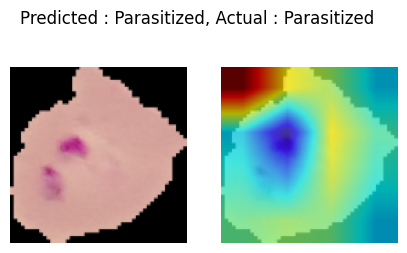

Activations shape:  torch.Size([1, 64, 4, 4])
Model weights shape of the last convolutional layer:  torch.Size([64, 512, 3, 3])
Activations shape after operations:  torch.Size([1, 64, 4, 4])
Heatmap shape:  (4, 4)


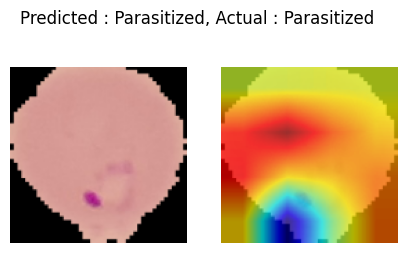

Activations shape:  torch.Size([1, 64, 4, 4])
Model weights shape of the last convolutional layer:  torch.Size([64, 512, 3, 3])
Activations shape after operations:  torch.Size([1, 64, 4, 4])
Heatmap shape:  (4, 4)


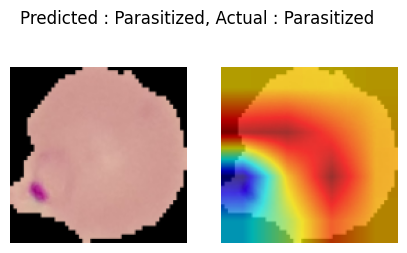

Activations shape:  torch.Size([1, 64, 4, 4])
Model weights shape of the last convolutional layer:  torch.Size([64, 512, 3, 3])
Activations shape after operations:  torch.Size([1, 64, 4, 4])
Heatmap shape:  (4, 4)


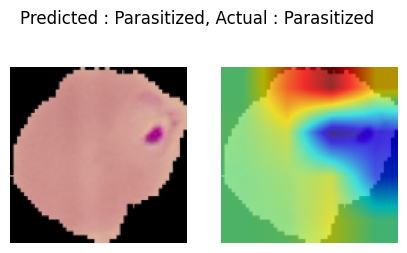

Activations shape:  torch.Size([1, 64, 4, 4])
Model weights shape of the last convolutional layer:  torch.Size([64, 512, 3, 3])
Activations shape after operations:  torch.Size([1, 64, 4, 4])
Heatmap shape:  (4, 4)


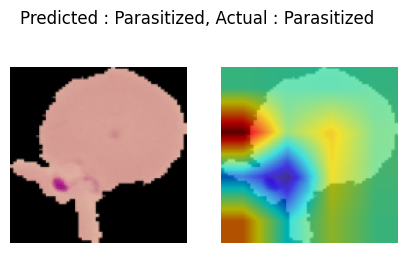

Activations shape:  torch.Size([1, 64, 4, 4])
Model weights shape of the last convolutional layer:  torch.Size([64, 512, 3, 3])
Activations shape after operations:  torch.Size([1, 64, 4, 4])
Heatmap shape:  (4, 4)


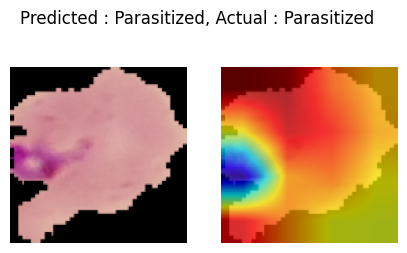

Activations shape:  torch.Size([1, 64, 4, 4])
Model weights shape of the last convolutional layer:  torch.Size([64, 512, 3, 3])
Activations shape after operations:  torch.Size([1, 64, 4, 4])
Heatmap shape:  (4, 4)


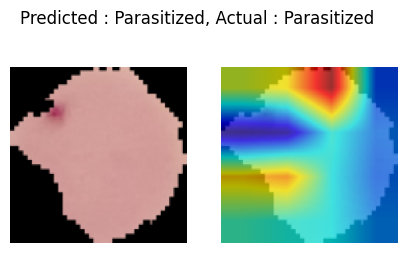

Activations shape:  torch.Size([1, 64, 4, 4])
Model weights shape of the last convolutional layer:  torch.Size([64, 512, 3, 3])
Activations shape after operations:  torch.Size([1, 64, 4, 4])
Heatmap shape:  (4, 4)


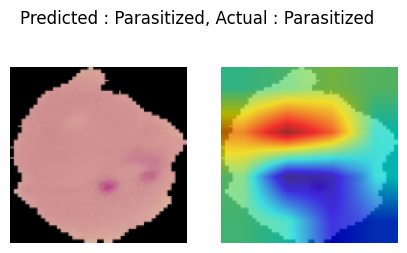

Activations shape:  torch.Size([1, 64, 4, 4])
Model weights shape of the last convolutional layer:  torch.Size([64, 512, 3, 3])
Activations shape after operations:  torch.Size([1, 64, 4, 4])
Heatmap shape:  (4, 4)


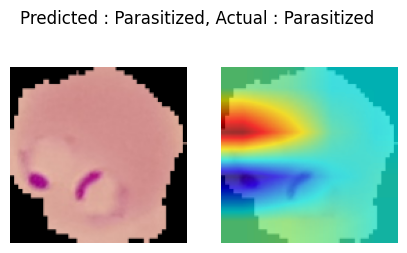

Activations shape:  torch.Size([1, 64, 4, 4])
Model weights shape of the last convolutional layer:  torch.Size([64, 512, 3, 3])
Activations shape after operations:  torch.Size([1, 64, 4, 4])
Heatmap shape:  (4, 4)


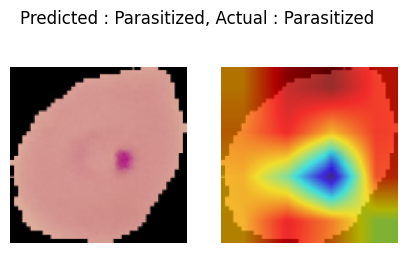

Activations shape:  torch.Size([1, 64, 4, 4])
Model weights shape of the last convolutional layer:  torch.Size([64, 512, 3, 3])
Activations shape after operations:  torch.Size([1, 64, 4, 4])
Heatmap shape:  (4, 4)


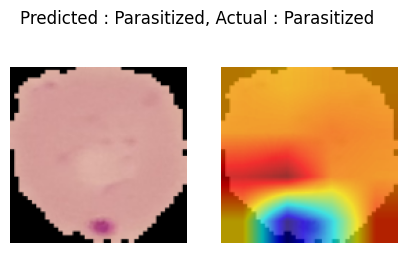

Activations shape:  torch.Size([1, 64, 4, 4])
Model weights shape of the last convolutional layer:  torch.Size([64, 512, 3, 3])
Activations shape after operations:  torch.Size([1, 64, 4, 4])
Heatmap shape:  (4, 4)


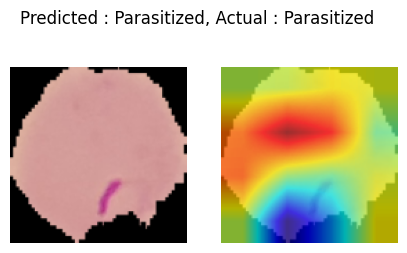

Activations shape:  torch.Size([1, 64, 4, 4])
Model weights shape of the last convolutional layer:  torch.Size([64, 512, 3, 3])
Activations shape after operations:  torch.Size([1, 64, 4, 4])
Heatmap shape:  (4, 4)


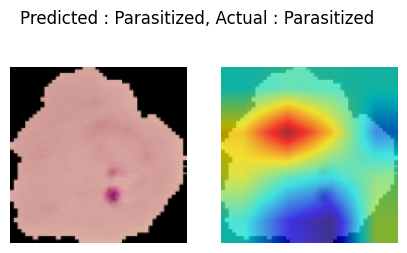

Activations shape:  torch.Size([1, 64, 4, 4])
Model weights shape of the last convolutional layer:  torch.Size([64, 512, 3, 3])
Activations shape after operations:  torch.Size([1, 64, 4, 4])
Heatmap shape:  (4, 4)


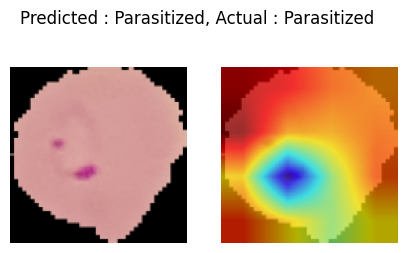

Activations shape:  torch.Size([1, 64, 4, 4])
Model weights shape of the last convolutional layer:  torch.Size([64, 512, 3, 3])
Activations shape after operations:  torch.Size([1, 64, 4, 4])
Heatmap shape:  (4, 4)


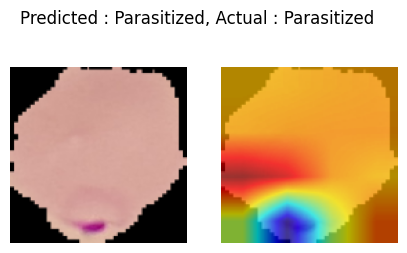

Activations shape:  torch.Size([1, 64, 4, 4])
Model weights shape of the last convolutional layer:  torch.Size([64, 512, 3, 3])
Activations shape after operations:  torch.Size([1, 64, 4, 4])
Heatmap shape:  (4, 4)


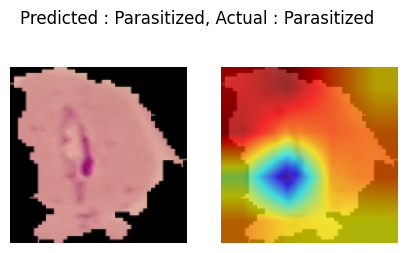

Activations shape:  torch.Size([1, 64, 4, 4])
Model weights shape of the last convolutional layer:  torch.Size([64, 512, 3, 3])
Activations shape after operations:  torch.Size([1, 64, 4, 4])
Heatmap shape:  (4, 4)


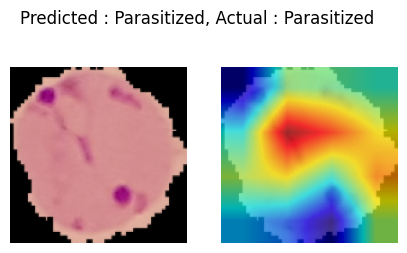

Activations shape:  torch.Size([1, 64, 4, 4])
Model weights shape of the last convolutional layer:  torch.Size([64, 512, 3, 3])
Activations shape after operations:  torch.Size([1, 64, 4, 4])
Heatmap shape:  (4, 4)


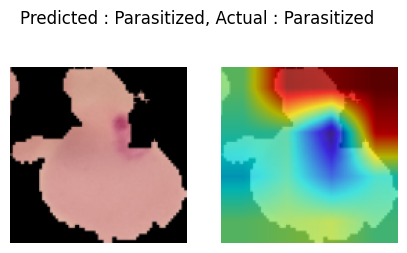

Activations shape:  torch.Size([1, 64, 4, 4])
Model weights shape of the last convolutional layer:  torch.Size([64, 512, 3, 3])
Activations shape after operations:  torch.Size([1, 64, 4, 4])
Heatmap shape:  (4, 4)


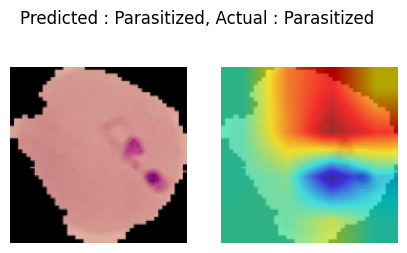

Activations shape:  torch.Size([1, 64, 4, 4])
Model weights shape of the last convolutional layer:  torch.Size([64, 512, 3, 3])
Activations shape after operations:  torch.Size([1, 64, 4, 4])
Heatmap shape:  (4, 4)


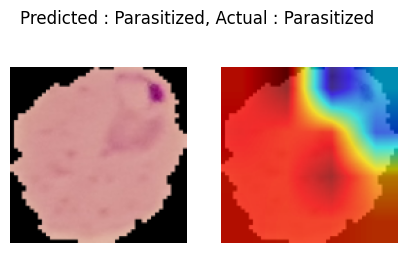

In [42]:
import matplotlib.pyplot as plt

N = 20
test_dataloader = DataLoader(dataset = test_dataset, batch_size = N, num_workers=0, shuffle=False)
images, labels = next(iter(test_dataloader))

for i in range(N):
  raw_img = denormalize(images[i]) # recomputing the raw image
  vis_img = cv2.resize(raw_img, (RESIZE_SIZE, RESIZE_SIZE))

  heatmap, pred = im2gradCAM(images[i:i+1].to(device)) 

  if(pred == "Uninfected"):
    continue

  heatmap = upsampleHeatmap(heatmap, vis_img)

  fig, axes = plt.subplots(1, 2, figsize=(5,3))
  axes[0].imshow(vis_img)
  axes[0].axis("off")
  axes[1].imshow(heatmap)
  axes[1].axis("off")
  fig.suptitle(f"Predicted : {pred}, Actual : {class_names[labels[i].item()]}")
  plt.show()

It passes the normalized input tensor `images[i:i+1]` into `im2gradCAM`.
The slice `[i:i+1]` keeps the batch dimension, so the input shape stays `(1, C, H, W)` instead of collapsing to `(C, H, W)`, which is what the model expects.
The function returns the raw `$H \times W$` heatmap and the string `pred` (`"Uninfected"` or `"Parasitized"`).

In [43]:
from pathlib import Path
from PIL import Image

def predict_and_show_cam(image_path: str = None, dataset_index: int = None):
  """Predict a single image and display the image plus its Grad-CAM overlay.
  Provide either `image_path` (str or Path) or `dataset_index` (index into `test_dataset`).
  """
  # ensure model is on the correct device
  model.to(device)
  model.eval()

  if dataset_index is not None:
    img_tensor, label = test_dataset[dataset_index]
    transformed = img_tensor
    actual = class_names[label]
  elif image_path is not None:
    p = Path(image_path)
    pil = Image.open(p).convert('RGB')
    transformed = val_transforms(pil)
    actual = 'Unknown'
  else:
    raise ValueError('Provide image_path or dataset_index')

  # prepare input tensor (add batch dim) and move to device
  input_tensor = transformed.unsqueeze(0).to(device)

  # generate heatmap and predicted label using existing im2gradCAM helper
  heatmap, pred = im2gradCAM(input_tensor)

  # recover a displayable original image (denormalize expects a (C,H,W) tensor)
  raw_img = denormalize(transformed)
  vis_img = cv2.resize(raw_img, (RESIZE_SIZE, RESIZE_SIZE))

  # overlay and show results
  cam = upsampleHeatmap(heatmap, vis_img)

  print(f'Predicted: {pred} | Actual: {actual}')
  fig, axes = plt.subplots(1,2, figsize=(8,4))
  axes[0].imshow(vis_img)
  axes[0].axis('off')
  axes[0].set_title('Original')
  axes[1].imshow(cam)
  axes[1].axis('off')
  axes[1].set_title('Grad-CAM Overlay')
  plt.show()

Activations shape:  torch.Size([1, 64, 4, 4])
Model weights shape of the last convolutional layer:  torch.Size([64, 512, 3, 3])
Activations shape after operations:  torch.Size([1, 64, 4, 4])
Heatmap shape:  (4, 4)
Predicted: Parasitized | Actual: Unknown


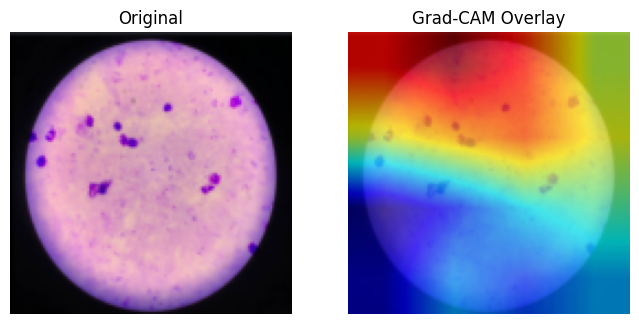

In [44]:
predict_and_show_cam(image_path="./test_image.png")